In [ ]:
pip install wordcloud

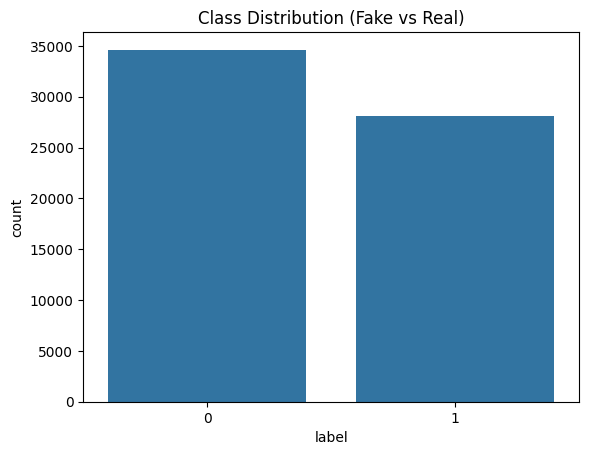

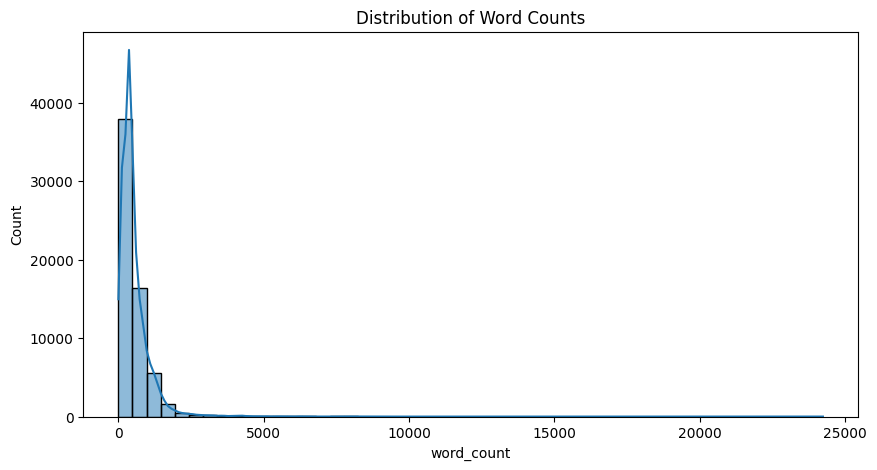

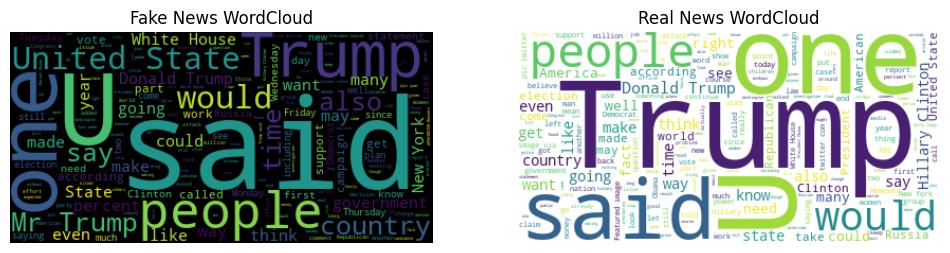

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter
import nltk
from nltk.corpus import stopwords
import re

# Load data
df = pd.read_pickle("../../data/processed/welfake_cleaned.pkl")

# 1. Class distribution
sns.countplot(x=df['label'])
plt.title("Class Distribution (Fake vs Real)")
plt.show()

# 2. Text length distribution
df['word_count'] = df['text'].apply(lambda x: len(str(x).split()))
df['char_count'] = df['text'].apply(lambda x: len(str(x)))

plt.figure(figsize=(10,5))
sns.histplot(df['word_count'], bins=50, kde=True)
plt.title("Distribution of Word Counts")
plt.show()

# 3. WordCloud for Fake news
real_text = " ".join(df[df['label']==1]['text'])
fake_text = " ".join(df[df['label']==0]['text'])

wc_fake = WordCloud(stopwords=set(stopwords.words('english')), background_color="black").generate(fake_text)
wc_real = WordCloud(stopwords=set(stopwords.words('english')), background_color="white").generate(real_text)

plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.imshow(wc_fake, interpolation="bilinear")
plt.title("Fake News WordCloud")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(wc_real, interpolation="bilinear")
plt.title("Real News WordCloud")
plt.axis("off")

plt.show()


In [6]:
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd

def get_top_ngrams(corpus, ngram_range=(2,2), n=None):
    """
    Extract top n n-grams from corpus
    """
    vec = CountVectorizer(ngram_range=ngram_range, stop_words='english').fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0)
    
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)
    
    return words_freq[:n]

# Fake news bigrams
fake_texts = df[df['label']==0]['text']
fake_bigrams = get_top_ngrams(fake_texts, ngram_range=(2,2), n=20)
fake_trigrams = get_top_ngrams(fake_texts, ngram_range=(3,3), n=20)

# Real news bigrams
real_texts = df[df['label']==1]['text']
real_bigrams = get_top_ngrams(real_texts, ngram_range=(2,2), n=20)
real_trigrams = get_top_ngrams(real_texts, ngram_range=(3,3), n=20)

# Convert to DataFrame for better visualization
print("Top Fake Bigrams:\n", pd.DataFrame(fake_bigrams, columns=['bigram','count']))
print("\nTop Real Bigrams:\n", pd.DataFrame(real_bigrams, columns=['bigram','count']))
print("\nTop Fake Trigrams:\n", pd.DataFrame(fake_trigrams, columns=['trigram','count']))
print("\nTop Real Trigrams:\n", pd.DataFrame(real_trigrams, columns=['trigram','count']))


Top Fake Bigrams:
                 bigram  count
0        united states  22063
1             mr trump  17552
2         donald trump  16803
3          white house  13881
4             new york  12804
5     president donald   7046
6   washington reuters   6639
7          north korea   6511
8        islamic state   6229
9      hillary clinton   6191
10          trump said   5886
11      prime minister   5618
12      said statement   5327
13        barack obama   4843
14       supreme court   4433
15         mrs clinton   4166
16   national security   3945
17     secretary state   3854
18      told reporters   3816
19    president barack   3787

Top Real Bigrams:
               bigram  count
0       donald trump  19296
1    hillary clinton  12523
2      united states   9056
3     featured image   7877
4        white house   7301
5        twitter com   5824
6        pic twitter   5516
7           new york   5303
8    president obama   4265
9       getty images   4135
10          fox news   

C:\Users\kknah\AppData\Local\Temp\ipykernel_9880\884913485.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="count", y="ngram", data=df_ngram, palette="viridis")


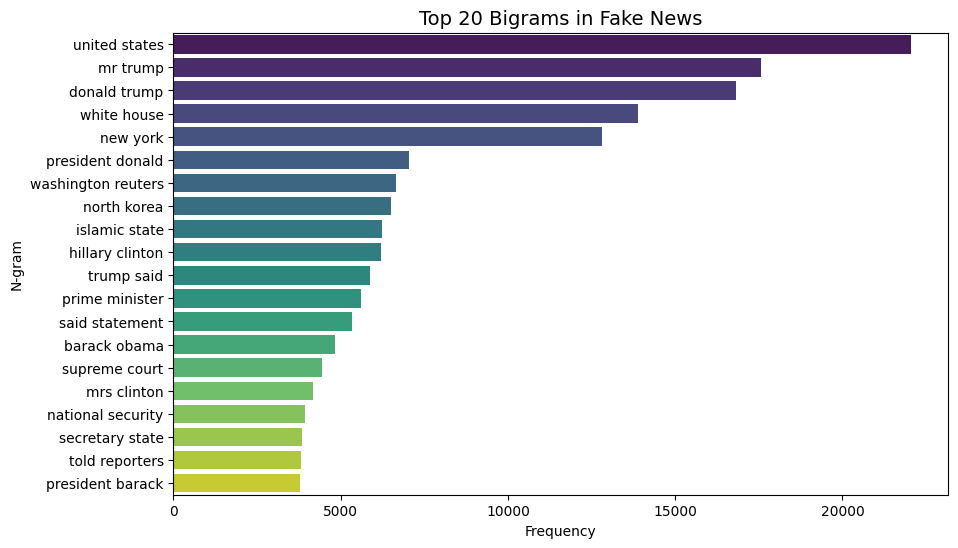

C:\Users\kknah\AppData\Local\Temp\ipykernel_9880\884913485.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="count", y="ngram", data=df_ngram, palette="viridis")


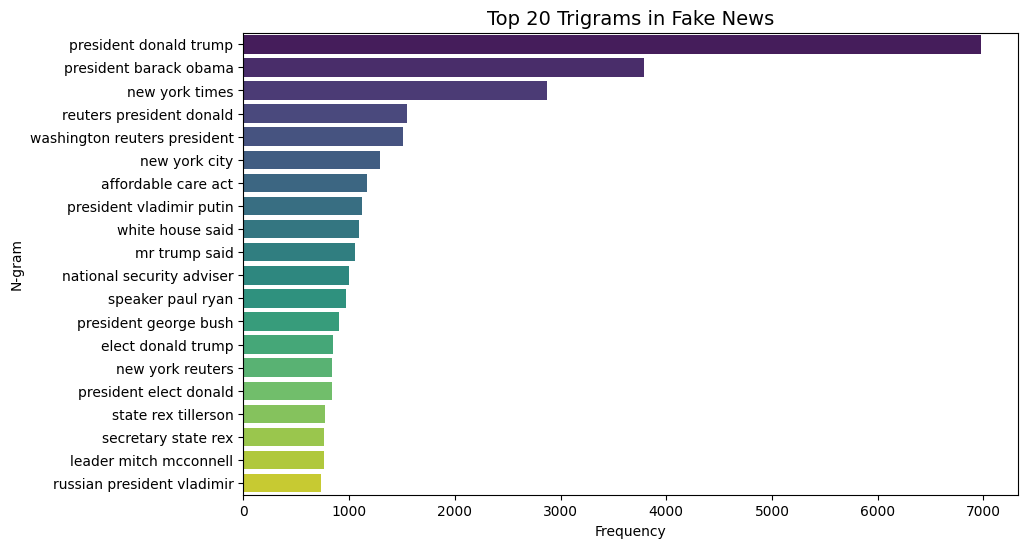

C:\Users\kknah\AppData\Local\Temp\ipykernel_9880\884913485.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="count", y="ngram", data=df_ngram, palette="viridis")


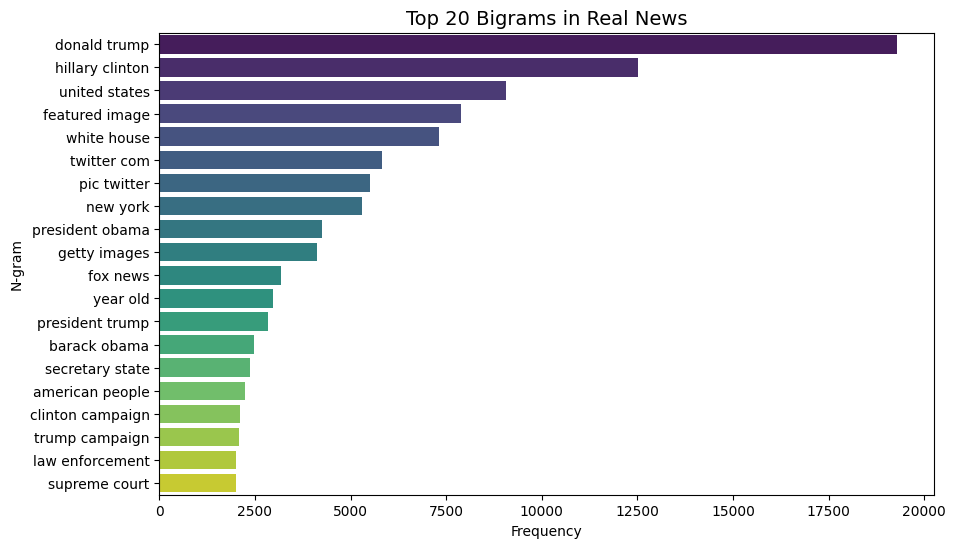

C:\Users\kknah\AppData\Local\Temp\ipykernel_9880\884913485.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="count", y="ngram", data=df_ngram, palette="viridis")


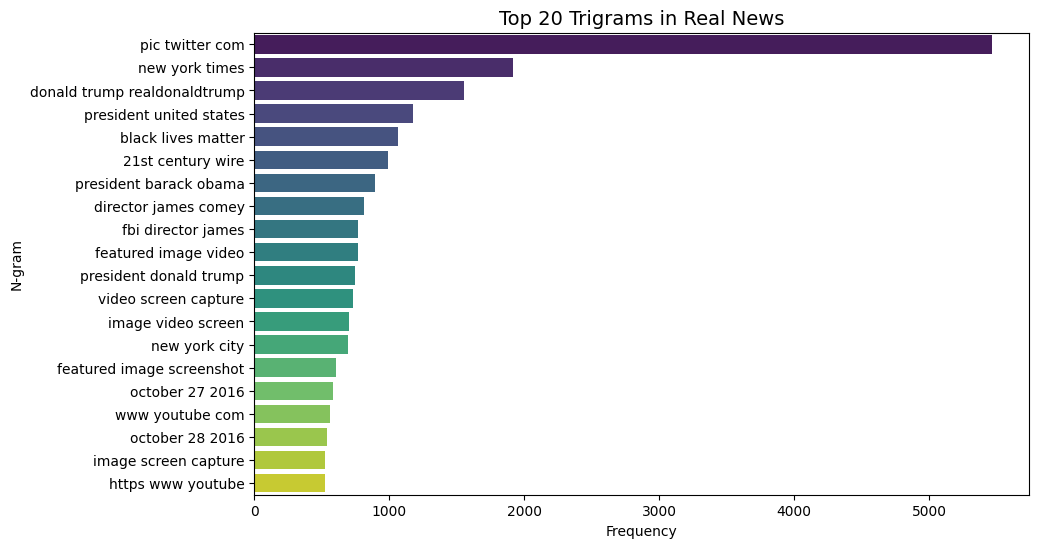

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_ngrams(ngrams, title, n=20):
    df_ngram = pd.DataFrame(ngrams, columns=["ngram", "count"])
    plt.figure(figsize=(10,6))
    sns.barplot(x="count", y="ngram", data=df_ngram, palette="viridis")
    plt.title(title, fontsize=14)
    plt.xlabel("Frequency")
    plt.ylabel("N-gram")
    plt.show()

# Fake news bigrams & trigrams
plot_ngrams(fake_bigrams, "Top 20 Bigrams in Fake News")
plot_ngrams(fake_trigrams, "Top 20 Trigrams in Fake News")

# Real news bigrams & trigrams
plot_ngrams(real_bigrams, "Top 20 Bigrams in Real News")
plot_ngrams(real_trigrams, "Top 20 Trigrams in Real News")
